
# MNIST Digit Classification using CNN - Student Workbook

## Learning Outcomes
After completing this notebook, students will be able to:

1. Understand the MNIST dataset.
2. Perform basic EDA.
3. Preprocess image data for CNN.
4. Build a CNN using TensorFlow/Keras.
5. Train and evaluate a model.
6. Interpret Confusion Matrix and Classification Report.
7. Predict a new handwritten digit image.

---

## What is CNN?

CNN (Convolutional Neural Network) is a Deep Learning model designed for image processing.

CNN automatically learns:
- Edges
- Curves
- Shapes
- Patterns

which makes it suitable for image classification tasks.



# MNIST Digit Classification Using CNN

## Workflow Covered

1. Load Train and Test CSV Files
2. Exploratory Data Analysis (EDA)
3. Dataset Description and Class Percentages
4. Data Preprocessing
5. CNN with 3 Convolution Layers
6. ReLU Activation
7. Dropout
8. Softmax Output Layer
9. Early Stopping
10. Accuracy and Loss Graphs
11. Overfitting Analysis
12. Confusion Matrix
13. Classification Report
14. Sample Predictions
15. Upload New Handwritten Digit Image
16. Predict User Uploaded Image



# Understanding the Libraries

### NumPy
Used for numerical operations and arrays.

### Pandas
Used to load and manipulate CSV datasets.

### Matplotlib
Used to display images and graphs.

### Seaborn
Used for advanced visualizations.

### TensorFlow / Keras
Framework used to build and train Deep Learning models.

### PIL
Used for reading and preprocessing uploaded images.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


## Mount Google Drive

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Load Train and Test CSV Files

In [ ]:

train_df = pd.read_csv('/content/drive/MyDrive/mnist_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/mnist_test.csv')

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

train_df.head()


Train Shape : (60000, 785)
Test Shape  : (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Dataset Description

In [ ]:

print("Rows :", train_df.shape[0])
print("Columns :", train_df.shape[1])

print("Missing Values :", train_df.isnull().sum().sum())


Rows : 60000
Columns : 785
Missing Values : 0


## Class Distribution

In [ ]:

class_count = train_df['label'].value_counts().sort_index()

class_percentage = (class_count/len(train_df))*100

print(class_count)

print("\nClass Percentage")
print(class_percentage.round(2))


label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

Class Percentage
label
0     9.87
1    11.24
2     9.93
3    10.22
4     9.74
5     9.04
6     9.86
7    10.44
8     9.75
9     9.92
Name: count, dtype: float64


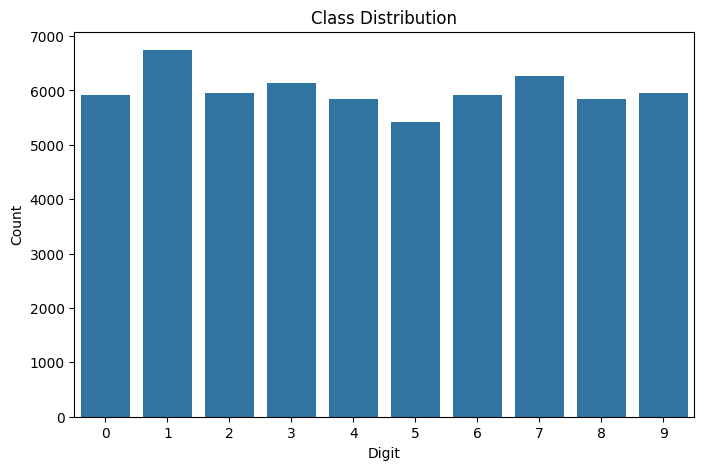

In [ ]:

plt.figure(figsize=(8,5))

sns.barplot(
    x=class_count.index,
    y=class_count.values
)

plt.title("Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")

plt.show()


## Display Sample Images

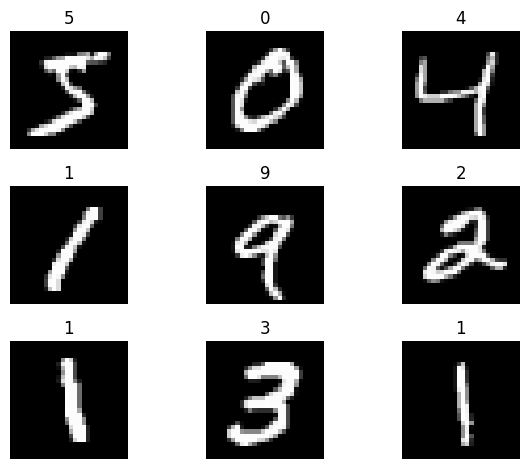

In [ ]:

for i in range(9):

    plt.subplot(3,3,i+1)

    image = train_df.iloc[i,1:].values.reshape(28,28)

    plt.imshow(image,cmap='gray')

    plt.title(train_df.iloc[i,0])

    plt.axis('off')

plt.tight_layout()
plt.show()


## Data Preprocessing

In [ ]:

X_train = train_df.iloc[:,1:].values
y_train = train_df.iloc[:,0].values

X_test = test_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values


In [ ]:

X_train = X_train/255.0
X_test = X_test/255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print(X_train.shape)
print(X_test.shape)


(60000, 28, 28, 1)
(10000, 28, 28, 1)


## CNN Model

In [ ]:

model = Sequential()

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [ ]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## Early Stopping

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


## Train CNN

In [ ]:

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.20,
    callbacks=[early_stop]
)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9014 - loss: 0.3190 - val_accuracy: 0.9799 - val_loss: 0.0712
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9769 - loss: 0.0803 - val_accuracy: 0.9831 - val_loss: 0.0546
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9832 - loss: 0.0557 - val_accuracy: 0.9880 - val_loss: 0.0417
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9870 - loss: 0.0453 - val_accuracy: 0.9875 - val_loss: 0.0438
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9892 - loss: 0.0358 - val_accuracy: 0.9888 - val_loss: 0.0379
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9911 - loss: 0.0300 - val_accuracy: 0.9898 - val_loss: 0.0346
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9915 - loss: 0.0259 - val_accuracy: 0.9877 - val_loss: 0.0414
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.

## Accuracy and Loss Graphs

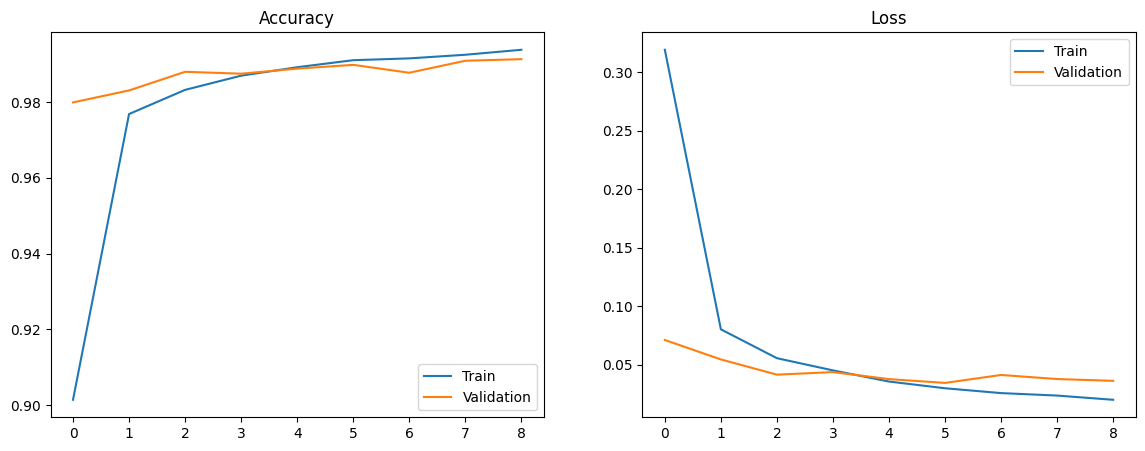

In [ ]:

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()


## Evaluate Model

In [ ]:

loss,accuracy = model.evaluate(X_test,y_test)

print("Test Loss :",loss)
print("Test Accuracy :",accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9912 - loss: 0.0253
Test Loss : 0.025306668132543564
Test Accuracy : 0.9911999702453613


## Predictions

In [ ]:

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob,axis=1)

y_actual = np.argmax(y_test,axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Classification Report

In [ ]:

print(classification_report(
    y_actual,
    y_pred
))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Confusion Matrix

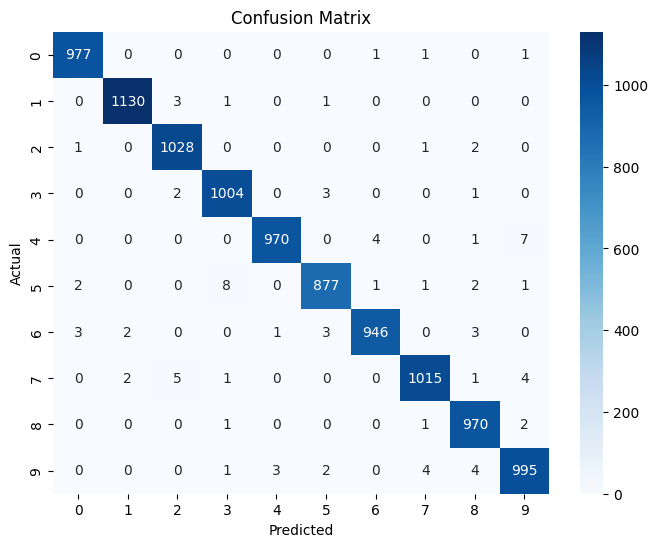

In [ ]:

cm = confusion_matrix(
    y_actual,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


## Show Test Predictions

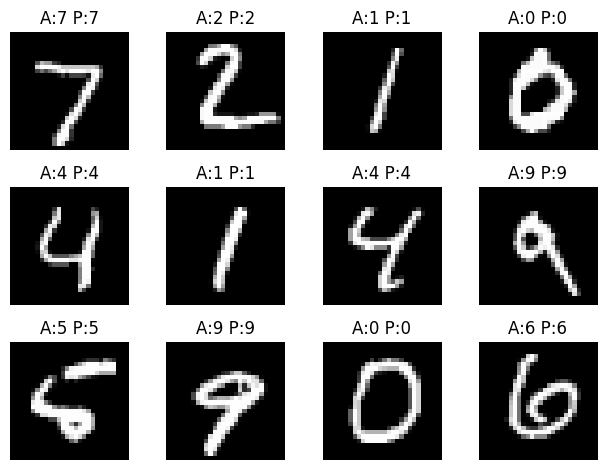

In [ ]:

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"A:{y_actual[i]} P:{y_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()


## Upload New Handwritten Digit

In [ ]:

from google.colab import files

uploaded = files.upload()


Saving 9.png to 9.png


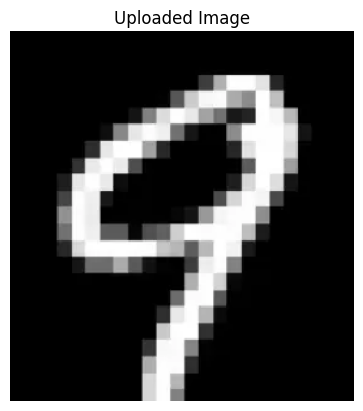

In [ ]:

from PIL import Image

filename = list(uploaded.keys())[0]

img = Image.open(filename)

plt.imshow(img)

plt.title("Uploaded Image")

plt.axis('off')

plt.show()


## Preprocess Uploaded Image

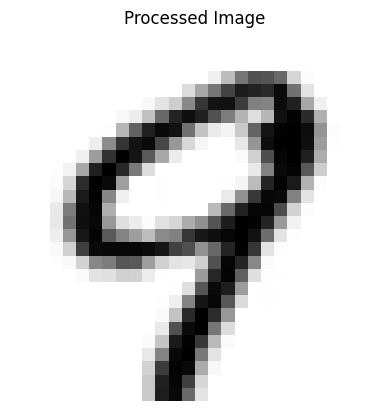

In [ ]:

from PIL import ImageOps

img = Image.open(filename)

img = img.convert('L')

img = ImageOps.invert(img)

img = img.resize((28,28))

plt.imshow(img,cmap='gray')

plt.title("Processed Image")

plt.axis('off')

plt.show()

img_array = np.array(img)

img_array = img_array/255.0

img_array = img_array.reshape(1,28,28,1)


## Predict Uploaded Digit

In [ ]:

prediction = model.predict(img_array)

predicted_digit = np.argmax(prediction)

confidence = np.max(prediction)*100

print("Predicted Digit :",predicted_digit)

print("Confidence : {:.2f}%".format(confidence))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
Predicted Digit : 9
Confidence : 81.37%


In [ ]:
from IPython.display import HTML
from google.colab.output import eval_js
from base64 import b64decode

canvas_html = """
<canvas id="canvas" width="280" height="280"
style="border:2px solid black;">
</canvas>

<br><br>

<button onclick="clearCanvas()">Clear</button>
<button onclick="saveCanvas()">Predict</button>

<script>

var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');

ctx.fillStyle = 'black';
ctx.fillRect(0,0,280,280);

ctx.strokeStyle='white';
ctx.lineWidth=20;

var drawing=false;

canvas.onmousedown=function(){
 drawing=true;
};

canvas.onmouseup=function(){
 drawing=false;
 ctx.beginPath();
};

canvas.onmousemove=function(e){

 if(!drawing) return;

 var rect=canvas.getBoundingClientRect();

 ctx.lineTo(
   e.clientX-rect.left,
   e.clientY-rect.top
 );

 ctx.stroke();

 ctx.beginPath();

 ctx.moveTo(
   e.clientX-rect.left,
   e.clientY-rect.top
 );
};

function clearCanvas(){

 ctx.fillStyle='black';

 ctx.fillRect(0,0,280,280);
}

function saveCanvas(){

 var dataURL=canvas.toDataURL();

 google.colab.kernel.invokeFunction(
    'notebook.save_image',
    [dataURL],
    {}
 );
}

</script>
"""

HTML(canvas_html)

In [ ]:
from google.colab import output

drawing_data = None

def save_image(data):

    global drawing_data

    drawing_data = data

output.register_callback(
    'notebook.save_image',
    save_image
)

In [ ]:
eval_js("saveCanvas()")

MessageError: ReferenceError: saveCanvas is not defined

## Softmax Probabilities

In [ ]:

for i,p in enumerate(prediction[0]):
    print(f"Digit {i} : {p*100:.2f}%")


Digit 0 : 0.95%
Digit 1 : 0.08%
Digit 2 : 5.16%
Digit 3 : 2.98%
Digit 4 : 0.11%
Digit 5 : 0.18%
Digit 6 : 0.02%
Digit 7 : 0.20%
Digit 8 : 8.95%
Digit 9 : 81.37%
